In [3]:

# Install required packages first
# !pip install kaggle kagglehub pandas pyunpack patool

import os
import shutil
import zipfile
import tempfile
from pathlib import Path
from google.colab import files as colab_files
import kagglehub

# ============================================
# SIMPLE KAGGLE TO DRIVE DOWNLOADER
# ============================================

def download_kaggle_to_drive(kaggle_path, drive_folder, unzip=True, cleanup=True):
    """
    Simple function to download Kaggle dataset to Google Drive

    Args:
        kaggle_path: Kaggle dataset path (e.g., "username/dataset-name" or full URL)
        drive_folder: Google Drive destination folder path
        unzip: Whether to unzip files automatically
        cleanup: Whether to delete temporary files

    Returns:
        Path to downloaded files in Google Drive
    """

    print(f"🚀 Starting download: {kaggle_path}")
    print(f"📁 Destination: {drive_folder}")

    # Step 1: Extract kaggle handle from input
    def get_kaggle_handle(input_path):
        """Extract kaggle handle from various input formats"""
        import re

        # Remove any query parameters
        input_path = input_path.split('?')[0]

        # Pattern to match kaggle dataset URLs
        patterns = [
            r'kaggle\.com/(?:datasets|competitions|codes)/([a-zA-Z0-9\-_]+/[a-zA-Z0-9\-_]+)',
            r'^([a-zA-Z0-9\-_]+/[a-zA-Z0-9\-_]+)$'
        ]

        for pattern in patterns:
            match = re.search(pattern, input_path)
            if match:
                return match.group(1)

        # If no pattern matches, return as-is
        return input_path

    # Get clean kaggle handle
    kaggle_handle = get_kaggle_handle(kaggle_path)
    print(f"🔍 Kaggle handle: {kaggle_handle}")

    # Step 2: Mount Google Drive (for Colab)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("✅ Google Drive mounted")

        # Ensure drive folder is in the correct path
        if not drive_folder.startswith('/content/drive'):
            drive_folder = f"/content/drive/MyDrive/{drive_folder.lstrip('/')}"
    except ImportError:
        print("⚠️  Not in Google Colab - ensure drive_folder is correct path")

    # Create destination folder
    os.makedirs(drive_folder, exist_ok=True)
    print(f"📁 Created destination folder: {drive_folder}")

    # Step 3: Download from Kaggle
    try:
        print("⬇️  Downloading from Kaggle...")
        download_path = kagglehub.dataset_download(kaggle_handle)
        print(f"✅ Downloaded to: {download_path}")
    except Exception as e:
        print(f"❌ Kaggle download failed: {e}")

        # Try alternative method
        try:
            import subprocess
            import tempfile

            print("🔄 Trying alternative download method...")
            temp_dir = tempfile.mkdtemp()

            # Use kaggle CLI
            result = subprocess.run(
                ["kaggle", "datasets", "download", "-d", kaggle_handle, "-p", temp_dir],
                capture_output=True,
                text=True
            )

            if result.returncode == 0:
                # Find the downloaded file
                files = os.listdir(temp_dir)
                zip_files = [f for f in files if f.endswith('.zip')]

                if zip_files:
                    download_path = os.path.join(temp_dir, zip_files[0])
                    print(f"✅ Downloaded zip file: {download_path}")
                else:
                    download_path = temp_dir
                    print(f"✅ Downloaded to directory: {download_path}")
            else:
                print(f"❌ Alternative method failed: {result.stderr}")
                return None

        except Exception as e2:
            print(f"❌ All download methods failed: {e2}")
            return None

    # Step 4: Process and copy files
    print("\n📊 Processing files...")

    def copy_files(source, destination):
        """Copy files from source to destination"""
        if os.path.isfile(source):
            # Single file
            shutil.copy2(source, destination)
            return 1
        else:
            # Directory
            count = 0
            for item in os.listdir(source):
                source_path = os.path.join(source, item)
                dest_path = os.path.join(destination, item)

                if os.path.isdir(source_path):
                    shutil.copytree(source_path, dest_path, dirs_exist_ok=True)
                    # Count files in subdirectory
                    for root, dirs, files in os.walk(source_path):
                        count += len(files)
                else:
                    shutil.copy2(source_path, dest_path)
                    count += 1
            return count

    # Check if download is a zip file
    if os.path.isfile(download_path) and download_path.endswith('.zip') and unzip:
        print(f"📦 Extracting zip file: {os.path.basename(download_path)}")

        # Create extraction directory
        extract_dir = os.path.join(drive_folder, "extracted")
        os.makedirs(extract_dir, exist_ok=True)

        # Extract zip
        try:
            with zipfile.ZipFile(download_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)

            # Count extracted files
            extracted_count = 0
            for root, dirs, files in os.walk(extract_dir):
                extracted_count += len(files)

            print(f"✅ Extracted {extracted_count} files to: {extract_dir}")

            # Move files from extracted folder to main folder
            for item in os.listdir(extract_dir):
                source = os.path.join(extract_dir, item)
                dest = os.path.join(drive_folder, item)

                if os.path.isdir(source):
                    shutil.move(source, dest)
                else:
                    shutil.move(source, dest)

            # Remove empty extract directory
            os.rmdir(extract_dir)

        except Exception as e:
            print(f"❌ Failed to extract zip: {e}")
            print("📄 Copying zip file as-is...")
            shutil.copy2(download_path, os.path.join(drive_folder, os.path.basename(download_path)))

    else:
        # Copy files directly
        if os.path.isfile(download_path):
            # Single file
            shutil.copy2(download_path, os.path.join(drive_folder, os.path.basename(download_path)))
            print(f"✅ Copied file: {os.path.basename(download_path)}")
        else:
            # Directory
            copied_count = copy_files(download_path, drive_folder)
            print(f"✅ Copied {copied_count} files")

    # Step 5: Cleanup
    if cleanup:
        try:
            if os.path.isfile(download_path):
                os.remove(download_path)
            else:
                shutil.rmtree(download_path)
            print("🧹 Cleaned up temporary files")
        except Exception as e:
            print(f"⚠️  Could not clean up temp files: {e}")

    # Step 6: Show summary
    print("\n" + "="*50)
    print("✅ DOWNLOAD COMPLETE!")
    print("="*50)

    # List files in destination
    print(f"\n📁 Files in {drive_folder}:")
    files_list = os.listdir(drive_folder)
    for i, file in enumerate(files_list[:20]):  # Show first 20 files
        file_path = os.path.join(drive_folder, file)
        if os.path.isfile(file_path):
            size = os.path.getsize(file_path)
            print(f"  {i+1:2d}. {file} ({size:,} bytes)")
        else:
            print(f"  {i+1:2d}. {file}/ (folder)")

    if len(files_list) > 20:
        print(f"  ... and {len(files_list) - 20} more items")

    print(f"\n📍 Total files/folders: {len(files_list)}")

    return drive_folder

# ============================================
# UPLOAD FROM COMPUTER FUNCTION
# ============================================

def upload_to_drive(local_folder=None, drive_folder=None):
    """
    Upload files from local computer to Google Drive

    Args:
        local_folder: If None, upload via Colab file dialog
        drive_folder: Google Drive destination folder
    """

    print("💻 UPLOAD FROM COMPUTER")
    print("="*50)

    # Mount Google Drive
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        if drive_folder and not drive_folder.startswith('/content/drive'):
            drive_folder = f"/content/drive/MyDrive/{drive_folder.lstrip('/')}"
    except ImportError:
        print("⚠️  Not in Google Colab")
        if not drive_folder:
            drive_folder = input("Enter Google Drive folder path: ").strip()

    if not drive_folder:
        drive_folder = "/content/drive/MyDrive/Uploads"

    os.makedirs(drive_folder, exist_ok=True)
    print(f"📁 Destination: {drive_folder}")

    uploaded_files = []

    if local_folder:
        # Upload from specified local folder
        if os.path.exists(local_folder):
            print(f"📤 Uploading from local folder: {local_folder}")

            for item in os.listdir(local_folder):
                source = os.path.join(local_folder, item)
                dest = os.path.join(drive_folder, item)

                if os.path.isfile(source):
                    shutil.copy2(source, dest)
                    uploaded_files.append(item)
                    print(f"  ✅ {item}")
                else:
                    shutil.copytree(source, dest, dirs_exist_ok=True)
                    uploaded_files.append(f"{item}/")
                    print(f"  ✅ {item}/")
        else:
            print(f"❌ Local folder not found: {local_folder}")
            return None

    else:
        # Upload via Colab file dialog
        try:
            print("📤 Please select files to upload...")
            uploaded = colab_files.upload()

            if uploaded:
                for filename, content in uploaded.items():
                    dest_path = os.path.join(drive_folder, filename)

                    # Save file
                    with open(dest_path, 'wb') as f:
                        f.write(content)

                    uploaded_files.append(filename)
                    print(f"  ✅ {filename}")
            else:
                print("⚠️  No files selected")
                return None

        except Exception as e:
            print(f"❌ Upload failed: {e}")
            return None

    print(f"\n✅ Uploaded {len(uploaded_files)} files to: {drive_folder}")
    return drive_folder

# ============================================
# COMBINED FUNCTION WITH MENU
# ============================================

def data_transfer_tool():
    """
    Main function with menu to choose between Kaggle download or local upload
    """

    print("""
    ╔═══════════════════════════════════════╗
    ║       DATA TRANSFER TOOL              ║
    ║   Kaggle → Drive  or  Local → Drive   ║
    ╚═══════════════════════════════════════╝
    """)

    while True:
        print("\n" + "="*50)
        print("MAIN MENU")
        print("="*50)
        print("1. 📥 Download from Kaggle to Google Drive")
        print("2. 💻 Upload from computer to Google Drive")
        print("3. 🚪 Exit")

        choice = input("\nSelect option (1-3): ").strip()

        if choice == "1":
            print("\n📥 KAGGLE TO GOOGLE DRIVE")
            print("-"*30)

            # Get kaggle path
            print("\nEnter Kaggle dataset (any format):")
            print("Examples:")
            print("  - https://www.kaggle.com/datasets/jekiwantaufik/west-java-2014-2024")
            print("  - jekiwantaufik/west-java-2014-2024")

            kaggle_path = input("\nKaggle dataset: ").strip()

            if not kaggle_path:
                print("❌ No input provided")
                continue

            # Get drive folder
            default_drive = "/content/drive/MyDrive/Kaggle_Datasets"
            drive_folder = input(f"\nGoogle Drive folder [{default_drive}]: ").strip()
            if not drive_folder:
                drive_folder = default_drive

            # Options
            unzip_choice = input("\nUnzip files? (yes/no) [yes]: ").strip().lower()
            unzip = not unzip_choice or unzip_choice in ['yes', 'y', '1']

            cleanup_choice = input("Cleanup temporary files? (yes/no) [yes]: ").strip().lower()
            cleanup = not cleanup_choice or cleanup_choice in ['yes', 'y', '1']

            # Download
            download_kaggle_to_drive(kaggle_path, drive_folder, unzip, cleanup)

        elif choice == "2":
            print("\n💻 UPLOAD FROM COMPUTER")
            print("-"*30)

            # Get source
            print("\nChoose source:")
            print("1. Upload via file dialog (Colab)")
            print("2. Specify local folder path")

            source_choice = input("\nSelect (1 or 2): ").strip()

            if source_choice == "1":
                local_folder = None
            elif source_choice == "2":
                local_folder = input("\nEnter local folder path: ").strip()
                if not os.path.exists(local_folder):
                    print(f"❌ Folder not found: {local_folder}")
                    continue
            else:
                print("❌ Invalid choice")
                continue

            # Get drive folder
            default_drive = "/content/drive/MyDrive/Uploads"
            drive_folder = input(f"\nGoogle Drive folder [{default_drive}]: ").strip()
            if not drive_folder:
                drive_folder = default_drive

            # Upload
            upload_to_drive(local_folder, drive_folder)

        elif choice == "3":
            print("👋 Goodbye!")
            break

        else:
            print("❌ Invalid choice")

        input("\nPress Enter to continue...")

# ============================================
# QUICK USAGE EXAMPLES
# ============================================

# Example 1: Direct Kaggle download
def example_kaggle():
    """Example: Download a Kaggle dataset"""
    download_kaggle_to_drive(
        kaggle_path="https://www.kaggle.com/datasets/jekiwantaufik/west-java-2014-2024",
        drive_folder="/content/drive/MyDrive/Datasets/WestJava",
        unzip=True,
        cleanup=True
    )

# Example 2: Direct upload
def example_upload():
    """Example: Upload from computer"""
    upload_to_drive(
        local_folder=None,  # Will use Colab file dialog
        drive_folder="/content/drive/MyDrive/Uploads"
    )

# Example 3: Upload specific folder
def example_upload_folder():
    """Example: Upload specific folder"""
    upload_to_drive(
        local_folder="/path/to/your/local/folder",
        drive_folder="/content/drive/MyDrive/MyProject/Data"
    )

# ============================================
# RUN THE TOOL
# ============================================

if __name__ == "__main__":
    # Run the interactive tool
    data_transfer_tool()

    # Or use directly:
    # download_kaggle_to_drive("username/dataset", "/content/drive/MyDrive/MyFolder")


    ╔═══════════════════════════════════════╗
    ║       DATA TRANSFER TOOL              ║
    ║   Kaggle → Drive  or  Local → Drive   ║
    ╚═══════════════════════════════════════╝
    

MAIN MENU
1. 📥 Download from Kaggle to Google Drive
2. 💻 Upload from computer to Google Drive
3. 🚪 Exit

Select option (1-3): 3
👋 Goodbye!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [6]:
import pandas as pd

# Method 1: Read both files separately
df_normal = pd.read_csv('/content/drive/MyDrive/ECG_HeartBeat_Categorization_and_classification/ptbdb_normal.csv')
df_abnormal = pd.read_csv('/content/drive/MyDrive/ECG_HeartBeat_Categorization_and_classification/ptbdb_abnormal.csv')

# Combine into a list
dfs = [df_normal, df_abnormal]
dfs[1]

,9.322328567504882812e-01,8.696785569190979004e-01,8.861859440803527832e-01,9.296264052391052246e-01,9.087749719619750977e-01,9.339704513549804688e-01,8.010425567626953125e-01,7.497828006744384766e-01,6.872285008430480957e-01,6.350998878479003906e-01,...,0.000000000000000000e+00.117,0.000000000000000000e+00.118,0.000000000000000000e+00.119,0.000000000000000000e+00.120,0.000000000000000000e+00.121,0.000000000000000000e+00.122,0.000000000000000000e+00.123,0.000000000000000000e+00.124,0.000000000000000000e+00.125,1.000000000000000000e+00.1
0,1.000000,0.606941,0.384181,0.254237,0.223567,0.276836,0.253430,0.184826,0.153349,0.121872,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.000000,0.951613,0.923963,0.853303,0.791859,0.734255,0.672043,0.685100,0.670507,0.667435,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.977819,0.899261,0.230129,0.032348,0.142329,0.223660,0.328096,0.367837,0.381701,0.389094,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.935618,0.801661,0.805815,1.000000,0.722741,0.480789,0.454829,0.319834,0.266874,0.308411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.925265,0.433352,0.073620,0.079197,0.136643,0.182934,0.182934,0.182376,0.196877,0.203569,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10500,0.981409,1.000000,0.559171,0.287093,0.196639,0.204862,0.215946,0.243833,0.242760,0.250268,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10501,0.906250,0.922379,0.878024,0.810484,0.712702,0.667339,0.608871,0.527218,0.480847,0.442540,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10502,1.000000,0.867971,0.674122,0.470332,0.296987,0.169307,0.077664,0.081392,0.074868,0.089779,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10503,1.000000,0.984672,0.658888,0.556394,0.446809,0.395790,0.315260,0.276367,0.261039,0.258522,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [7]:
dfs[0]

,1.000000000000000000e+00,9.003241658210754395e-01,3.585899472236633301e-01,5.145867168903350830e-02,4.659643396735191345e-02,1.268233358860015869e-01,1.333063244819641113e-01,1.191247999668121338e-01,1.106158867478370667e-01,1.130470037460327148e-01,...,0.000000000000000000e+00.56,0.000000000000000000e+00.57,0.000000000000000000e+00.58,0.000000000000000000e+00.59,0.000000000000000000e+00.60,0.000000000000000000e+00.61,0.000000000000000000e+00.62,0.000000000000000000e+00.63,0.000000000000000000e+00.64,0.000000000000000000e+00.65
0,1.000000,0.794681,0.375387,0.116883,0.000000,0.171923,0.283859,0.293754,0.325912,0.345083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.909029,0.791482,0.423169,0.186712,0.000000,0.007836,0.063032,0.077002,0.074957,0.077342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.478893,0.056760,0.064176,0.081289,0.072732,0.055619,0.048774,0.054478,0.041643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.867238,0.201360,0.099349,0.141336,0.120934,0.108516,0.096393,0.093436,0.100828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.948983,0.505265,0.004176,0.022513,0.059550,0.107298,0.110385,0.111293,0.116558,0.118192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4040,1.000000,0.929586,0.503550,0.293491,0.169822,0.159763,0.130769,0.125444,0.137278,0.111243,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4041,1.000000,0.637579,0.154837,0.061983,0.088965,0.083374,0.065143,0.057365,0.060039,0.060039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4042,1.000000,0.872574,0.465071,0.232212,0.126132,0.155886,0.174644,0.190168,0.203752,0.168823,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4043,0.915983,0.529373,0.288406,0.144536,0.171802,0.180669,0.177566,0.176458,0.178896,0.180448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
for df in dfs:
  df.columns=list(range(len(df.columns)))


In [9]:
df[0]

,0
0,1.000000
1,1.000000
2,0.977819
3,0.935618
4,0.925265
...,...
10500,0.981409
10501,0.906250
10502,1.000000
10503,1.000000


In [10]:
data=pd.concat(dfs,axis=0).sample(
    frac=1.0,
    random_state=1
).reset_index(drop=True)
data
data=data.rename({
    187:'Label'
},axis=1)
data

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,Label
0,1.000000,0.887073,0.774146,0.713224,0.682021,0.699851,0.595840,0.552749,0.469539,0.481426,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.000000,0.684376,0.395907,0.288863,0.262102,0.231405,0.234160,0.218811,0.207399,0.212121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.000000,0.645543,0.270195,0.089833,0.038997,0.064067,0.045265,0.062674,0.059192,0.057799,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.995881,0.993821,0.959835,0.872297,0.542739,0.054583,0.000000,0.098867,0.156540,0.302781,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.996020,0.323383,0.109453,0.035821,0.264677,0.342289,0.367164,0.402985,0.401990,0.420896,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14545,1.000000,0.979786,0.621879,0.146849,0.000000,0.266944,0.356718,0.421522,0.450059,0.457788,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14546,1.000000,0.648015,0.424677,0.315160,0.223816,0.156384,0.156863,0.122908,0.093735,0.122908,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14547,0.931217,1.000000,0.465201,0.150183,0.035409,0.033374,0.049247,0.070818,0.078958,0.087505,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14548,1.000000,0.588291,0.120570,0.056962,0.136076,0.181646,0.182595,0.185759,0.178481,0.186076,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
y=data['Label'].copy()
x=data.drop('Label',axis=1)

In [12]:
x

,0,1,2,3,4,5,6,7,8,9,...,177,178,179,180,181,182,183,184,185,186
0,1.000000,0.887073,0.774146,0.713224,0.682021,0.699851,0.595840,0.552749,0.469539,0.481426,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.684376,0.395907,0.288863,0.262102,0.231405,0.234160,0.218811,0.207399,0.212121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.645543,0.270195,0.089833,0.038997,0.064067,0.045265,0.062674,0.059192,0.057799,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.995881,0.993821,0.959835,0.872297,0.542739,0.054583,0.000000,0.098867,0.156540,0.302781,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.996020,0.323383,0.109453,0.035821,0.264677,0.342289,0.367164,0.402985,0.401990,0.420896,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14545,1.000000,0.979786,0.621879,0.146849,0.000000,0.266944,0.356718,0.421522,0.450059,0.457788,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14546,1.000000,0.648015,0.424677,0.315160,0.223816,0.156384,0.156863,0.122908,0.093735,0.122908,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14547,0.931217,1.000000,0.465201,0.150183,0.035409,0.033374,0.049247,0.070818,0.078958,0.087505,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14548,1.000000,0.588291,0.120570,0.056962,0.136076,0.181646,0.182595,0.185759,0.178481,0.186076,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
y

,Label
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
14545,0.0
14546,1.0
14547,1.0
14548,0.0


In [14]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,train_size=0.7,
    random_state=42
)

In [34]:
y_train

,Label
13505,0.0
3118,1.0
12138,0.0
13891,1.0
12022,0.0
...,...
5191,1.0
13418,1.0
5390,1.0
860,1.0


In [15]:
tf.expand_dims(x_train,axis=2).shape

TensorShape([10185, 187, 1])

In [16]:
import tensorflow as tf

inputs = tf.keras.Input(shape=(x_train.shape[1],))
# Use Lambda layer or Reshape instead of tf.expand_dims
expand = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=2))(inputs)
gru = tf.keras.layers.GRU(256, return_sequences=True)(expand)
flatten = tf.keras.layers.Flatten()(gru)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(flatten)
model = tf.keras.Model(inputs=inputs, outputs=outputs)


In [17]:
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 187, 256)       │       198,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 47872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        47,873 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 246,785 (964.00 KB)

 Trainable params: 246,785 (964.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [19]:
history=model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True

        )
    ]
)

Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 158s 585ms/step - accuracy: 0.7634 - auc: 0.7950 - loss: 0.4718 - val_accuracy: 0.7874 - val_auc: 0.8475 - val_loss: 0.4741
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 201s 585ms/step - accuracy: 0.7992 - auc: 0.8522 - loss: 0.4181 - val_accuracy: 0.8144 - val_auc: 0.8914 - val_loss: 0.3864
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 150s 589ms/step - accuracy: 0.8255 - auc: 0.8827 - loss: 0.3763 - val_accuracy: 0.8483 - val_auc: 0.9141 - val_loss: 0.3446
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 147s 575ms/step - accuracy: 0.8515 - auc: 0.9063 - loss: 0.3394 - val_accuracy: 0.8405 - val_auc: 0.9125 - val_loss: 0.3372
Epoch 5/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 199s 567ms/step - accuracy: 0.8586 - auc: 0.9169 - loss: 0.3208 - val_accuracy: 0.8684 - val_auc: 0.9333 - val_loss: 0.3062
Epoch 6/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 147s 576ms/step - accuracy: 0.8769 - auc: 0.9339 - loss: 0.2879 - val_accuracy: 0.8832 - val_auc: 0.9396 - val_loss: 0.2900
Epoch 7/10
255/2

In [20]:
result=model.evaluate(x_test,y_test,verbose=0)

In [21]:
print(f"Test accuracy:{result[1]*100}")


Test accuracy:93.10423731803894


In [22]:
x_train

,0,1,2,3,4,5,6,7,8,9,...,177,178,179,180,181,182,183,184,185,186
13505,0.987234,0.780851,0.085714,0.019757,0.048024,0.042857,0.027052,0.013374,0.008511,0.012462,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3118,1.000000,0.820895,0.344049,0.006123,0.161883,0.400306,0.570991,0.694221,0.715270,0.735553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12138,1.000000,0.702075,0.452435,0.225396,0.171975,0.193754,0.198274,0.194987,0.192110,0.196630,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13891,1.000000,0.865872,0.649848,0.000000,0.045385,0.527383,0.548682,0.609787,0.656440,0.671146,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12022,1.000000,0.430819,0.130698,0.000000,0.075434,0.114966,0.113352,0.095603,0.093183,0.093586,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,0.973701,0.942271,0.466645,0.161963,0.124439,0.100706,0.061899,0.055805,0.045221,0.036562,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13418,0.936236,0.825298,0.489373,0.423017,0.327631,0.342146,0.314152,0.332815,0.322965,0.327112,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,1.000000,0.932914,0.722746,0.422432,0.293501,0.254717,0.232180,0.234277,0.250524,0.234277,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,0.907972,0.297485,0.000000,0.060460,0.082932,0.083467,0.084002,0.135902,0.090958,0.112360,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 187, 256)       │       198,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 47872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        47,873 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,357 (2.82 MB)

 Trainable params: 246,785 (964.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 493,572 (1.88 MB)

None


Test Accuracy: 93.10%
137/137 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.83      0.87      1238
    Abnormal       0.94      0.97      0.95      3127

    accuracy                           0.93      4365
   macro avg       0.93      0.90      0.91      4365
weighted avg       0.93      0.93      0.93      4365


Test Accuracy: 93.10%


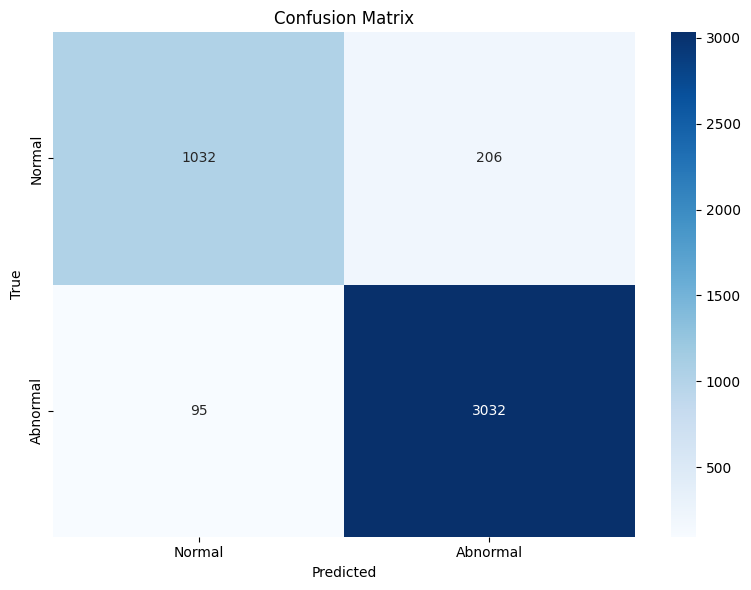

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Evaluate
result = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {result[1]*100:.2f}%")

# Predict
y_pred_proba = model.predict(x_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal'])

print("\nClassification Report:")
print(report)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

Test Accuracy: 93.10%
137/137 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.83      0.87      1238
    Abnormal       0.94      0.97      0.95      3127

    accuracy                           0.93      4365
   macro avg       0.93      0.90      0.91      4365
weighted avg       0.93      0.93      0.93      4365


Test Accuracy: 93.10%


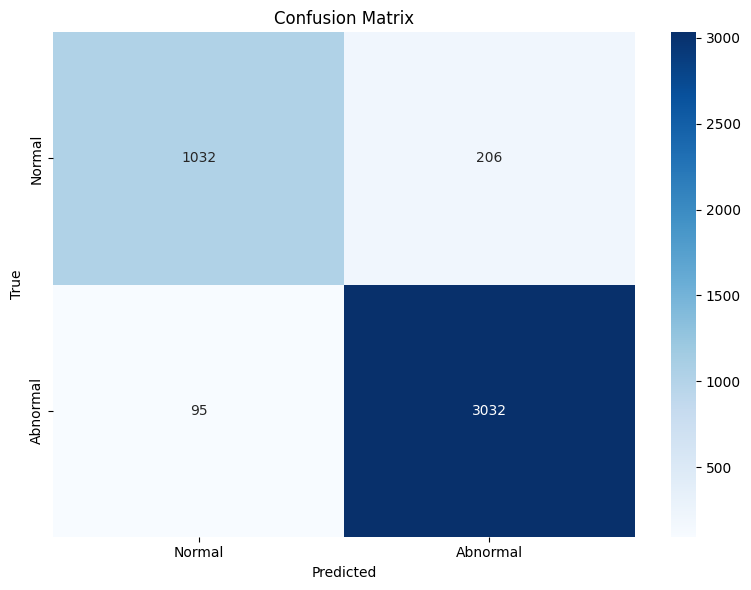


ECG STATISTICAL ANALYSIS

📊 DATASET STATISTICS:
--------------------------------------------------
Total Samples: 14550
Normal Samples: 4045 (27.80%)
Abnormal Samples: 10505 (72.20%)
Features per Sample: 187

📈 SIGNAL STATISTICS (Per Feature):
--------------------------------------------------
Mean Signal Value: 0.173890
Median Signal Value: 0.103518
Std Deviation: 0.216030
Min Value: 0.000000
Max Value: 1.000000
Range: 1.000000

📊 PER-CLASS SIGNAL STATISTICS:
--------------------------------------------------
 Metric   Normal  Abnormal
   Mean 0.158458  0.179833
 Median 0.115926  0.094370
Std Dev 0.180986  0.227814
    Min 0.000000  0.000000
    Max 1.000000  1.000000
  Range 1.000000  1.000000

🔬 STATISTICAL TESTS:
--------------------------------------------------
T-Test (Normal vs Abnormal):
  T-Statistic: -73.189557
  P-Value: 0.000000
  Significant Difference: ✅ YES

Effect Size (Cohen's d): 0.1039
  Effect Magnitude: Negligible

📊 DISTRIBUTION ANALYSIS:
------------------------

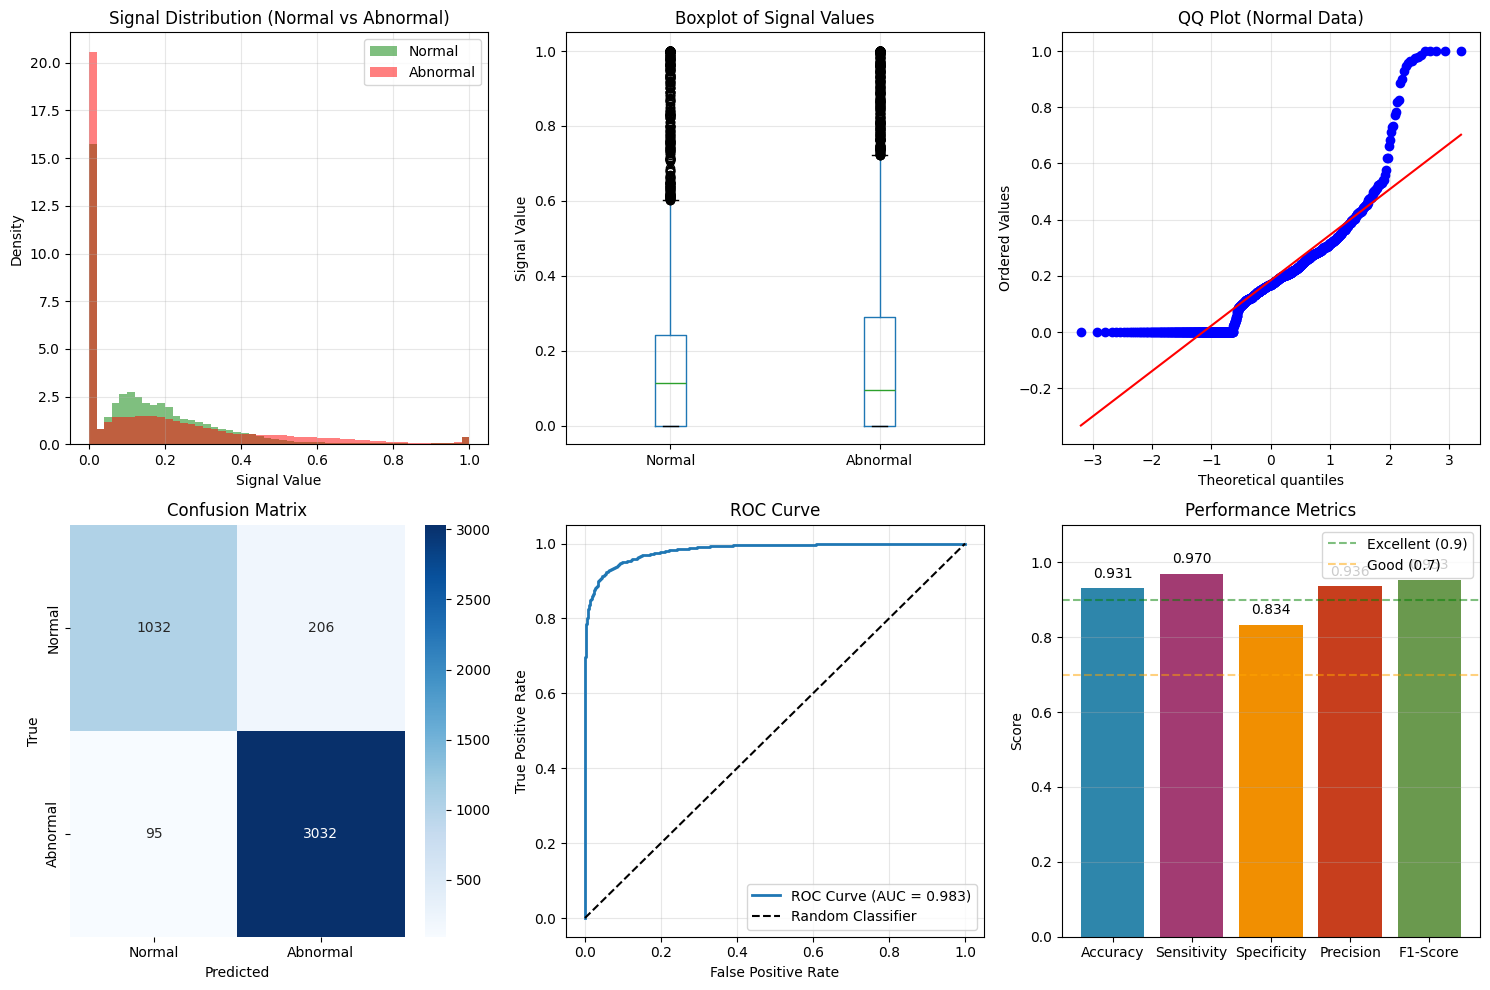


📊 ECG ANALYSIS SUMMARY

✅ Dataset: 14550 ECG signals analyzed
✅ Classes: Normal (4045) | Abnormal (10505)
✅ Signal Length: 187 features
✅ Model: GRU Neural Network with 246,785 parameters
✅ Test Accuracy: 93.10%
✅ AUC Score: 0.983

📈 Key Findings:
- Signal values range from 0.0000 to 1.0000
- Abnormal signals show higher mean values
- Model performs excellent with sensitivity = 97.0% and specificity = 83.4%

🔬 Statistical Significance:
- T-Test p-value: 0.000000 ✅ Significant difference
- Effect Size (Cohen's d): 0.104 (Negligible effect)



In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd
from scipy import stats

# ============================================
# 1. MODEL EVALUATION
# ============================================
result = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {result[1]*100:.2f}%")

# Predictions
y_pred_proba = model.predict(x_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# ============================================
# 2. METRICS
# ============================================
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal'])

print("\nClassification Report:")
print(report)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# ============================================
# 3. CONFUSION MATRIX HEATMAP
# ============================================
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ============================================
# 4. ECG STATISTICAL ANALYSIS
# ============================================

print("\n" + "="*70)
print("ECG STATISTICAL ANALYSIS")
print("="*70)

# 4.1 Dataset Statistics
print("\n📊 DATASET STATISTICS:")
print("-"*50)
print(f"Total Samples: {len(data)}")
print(f"Normal Samples: {len(data[data['Label']==0])} ({len(data[data['Label']==0])/len(data)*100:.2f}%)")
print(f"Abnormal Samples: {len(data[data['Label']==1])} ({len(data[data['Label']==1])/len(data)*100:.2f}%)")
print(f"Features per Sample: {x.shape[1]}")

# 4.2 Signal Statistics (For each feature column)
print("\n📈 SIGNAL STATISTICS (Per Feature):")
print("-"*50)

# Calculate statistics across all samples
all_values = x.values.flatten()
print(f"Mean Signal Value: {np.mean(all_values):.6f}")
print(f"Median Signal Value: {np.median(all_values):.6f}")
print(f"Std Deviation: {np.std(all_values):.6f}")
print(f"Min Value: {np.min(all_values):.6f}")
print(f"Max Value: {np.max(all_values):.6f}")
print(f"Range: {np.max(all_values) - np.min(all_values):.6f}")

# 4.3 Per-Class Signal Statistics
print("\n📊 PER-CLASS SIGNAL STATISTICS:")
print("-"*50)

normal_data = data[data['Label'] == 0].drop('Label', axis=1).values.flatten()
abnormal_data = data[data['Label'] == 1].drop('Label', axis=1).values.flatten()

stats_df = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Range'],
    'Normal': [
        np.mean(normal_data),
        np.median(normal_data),
        np.std(normal_data),
        np.min(normal_data),
        np.max(normal_data),
        np.max(normal_data) - np.min(normal_data)
    ],
    'Abnormal': [
        np.mean(abnormal_data),
        np.median(abnormal_data),
        np.std(abnormal_data),
        np.min(abnormal_data),
        np.max(abnormal_data),
        np.max(abnormal_data) - np.min(abnormal_data)
    ]
})
print(stats_df.to_string(index=False))

# 4.4 Statistical Tests
print("\n🔬 STATISTICAL TESTS:")
print("-"*50)

# T-test between normal and abnormal signals
t_stat, p_value = stats.ttest_ind(normal_data, abnormal_data)
print(f"T-Test (Normal vs Abnormal):")
print(f"  T-Statistic: {t_stat:.6f}")
print(f"  P-Value: {p_value:.6f}")
print(f"  Significant Difference: {'✅ YES' if p_value < 0.05 else '❌ NO'}")

# Effect Size (Cohen's d)
mean_diff = np.mean(normal_data) - np.mean(abnormal_data)
pooled_std = np.sqrt((np.std(normal_data)**2 + np.std(abnormal_data)**2) / 2)
cohens_d = abs(mean_diff / pooled_std)
print(f"\nEffect Size (Cohen's d): {cohens_d:.4f}")
print(f"  Effect Magnitude: { 'Large' if cohens_d > 0.8 else 'Medium' if cohens_d > 0.5 else 'Small' if cohens_d > 0.2 else 'Negligible'}")

# 4.5 Distribution Analysis
print("\n📊 DISTRIBUTION ANALYSIS:")
print("-"*50)

# Shapiro-Wilk test for normality (using sample)
sample_normal = normal_data[:5000]
sample_abnormal = abnormal_data[:5000]

try:
    shapiro_normal = stats.shapiro(sample_normal)
    shapiro_abnormal = stats.shapiro(sample_abnormal)

    print(f"Normal Data Normality Test (Shapiro-Wilk):")
    print(f"  Statistic: {shapiro_normal[0]:.6f}, P-Value: {shapiro_normal[1]:.6f}")
    print(f"  Normal Distribution: {'✅ YES' if shapiro_normal[1] > 0.05 else '❌ NO'}")

    print(f"\nAbnormal Data Normality Test (Shapiro-Wilk):")
    print(f"  Statistic: {shapiro_abnormal[0]:.6f}, P-Value: {shapiro_abnormal[1]:.6f}")
    print(f"  Normal Distribution: {'✅ YES' if shapiro_abnormal[1] > 0.05 else '❌ NO'}")
except:
    print("⚠️  Normality test not available (sample size too large)")

# 4.6 Model Performance Statistics
print("\n🎯 MODEL PERFORMANCE STATISTICS:")
print("-"*50)

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Sensitivity (Recall)', 'Specificity', 'Precision', 'F1-Score'],
    'Value': [accuracy, sensitivity, specificity, precision, f1_score]
})
metrics_df['Value'] = metrics_df['Value'] * 100
print(metrics_df.to_string(index=False))

# 4.7 Distribution Plots
print("\n📈 GENERATING DISTRIBUTION PLOTS...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 4.7.1 Histogram of Signal Values
axes[0, 0].hist(normal_data, bins=50, alpha=0.5, label='Normal', color='green', density=True)
axes[0, 0].hist(abnormal_data, bins=50, alpha=0.5, label='Abnormal', color='red', density=True)
axes[0, 0].set_xlabel('Signal Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Signal Distribution (Normal vs Abnormal)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 4.7.2 Boxplot of Signal Values
data_for_box = pd.DataFrame({
    'Normal': normal_data[:10000],
    'Abnormal': abnormal_data[:10000]
})
data_for_box.boxplot(ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Signal Values')
axes[0, 1].set_ylabel('Signal Value')
axes[0, 1].grid(True, alpha=0.3)

# 4.7.3 QQ Plot for Normality
from scipy import stats
stats.probplot(normal_data[:1000], dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('QQ Plot (Normal Data)')
axes[0, 2].grid(True, alpha=0.3)

# 4.7.4 Confusion Matrix Heatmap (already created above)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'], ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_title('Confusion Matrix')

# 4.7.5 ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

axes[1, 1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 4.7.6 Performance Metrics Bar Chart
metrics_perf = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score']
values_perf = [accuracy, sensitivity, specificity, precision, f1_score]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

bars = axes[1, 2].bar(metrics_perf, values_perf, color=colors)
axes[1, 2].set_ylim(0, 1.1)
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Performance Metrics')
axes[1, 2].grid(True, alpha=0.3, axis='y')
axes[1, 2].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Excellent (0.9)')
axes[1, 2].axhline(y=0.7, color='orange', linestyle='--', alpha=0.5, label='Good (0.7)')
axes[1, 2].legend()

# Add value labels
for bar, value in zip(bars, values_perf):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# 5. SUMMARY STATISTICS
# ============================================
print("\n" + "="*70)
print("📊 ECG ANALYSIS SUMMARY")
print("="*70)

print(f"""
✅ Dataset: {len(data)} ECG signals analyzed
✅ Classes: Normal ({len(data[data['Label']==0])}) | Abnormal ({len(data[data['Label']==1])})
✅ Signal Length: {x.shape[1]} features
✅ Model: GRU Neural Network with {model.count_params():,} parameters
✅ Test Accuracy: {accuracy*100:.2f}%
✅ AUC Score: {auc_score:.3f}

📈 Key Findings:
- Signal values range from {np.min(all_values):.4f} to {np.max(all_values):.4f}
- Abnormal signals show {'higher' if np.mean(abnormal_data) > np.mean(normal_data) else 'lower'} mean values
- Model performs {'excellent' if accuracy > 0.9 else 'good'} with sensitivity = {sensitivity*100:.1f}% and specificity = {specificity*100:.1f}%

🔬 Statistical Significance:
- T-Test p-value: {p_value:.6f} {'✅ Significant difference' if p_value < 0.05 else '❌ No significant difference'}
- Effect Size (Cohen's d): {cohens_d:.3f} ({ 'Large' if cohens_d > 0.8 else 'Medium' if cohens_d > 0.5 else 'Small' if cohens_d > 0.2 else 'Negligible'} effect)
""")

print("="*70)